<a href="https://colab.research.google.com/github/L0ADIN9/2D-Animation-Creator/blob/main/Pixel_Art_Interpolation(Mar%2017th%2C%202026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Preperation**
Downloading and importing datasets, files and functions.





In [1]:

#@title Imports/Download Dataset

!pip install tf2onnx
!pip install coremltools



import random

import numpy as np
import tensorflow as tf
import pandas as pd



import requests
import json
import glob
import os
import PIL
import tempfile
from PIL import Image
from google.colab import drive
from tensorflow.python.framework import graph_util
from tensorflow.python.framework import ops
from tensorflow.keras import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.python.keras import backend as K
from tensorflow.python.keras.models import load_model
import tf2onnx
import onnx



!git clone https://github.com/L0ADIN9/PAG_Dataset.git
!unzip /content/PAG_Dataset/Single_Sprite_Sheet.zip



#Plotting Import
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.style.use('bmh')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.9 MB/s eta 0:00:00
Cloning into 'PAG_Dataset'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 50 (delta 0), reused 0 (delta 0), pack-reused 49 (from 1)
Receiving objects: 100% (50/50), 2.81 MiB | 35.12 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Archive:  /content/PAG_Dataset/Single_Sprite_Sheet.zip
   creating: Single_Sprite_Sheet/
  inflating: __MACOSX/._Single_Sprite_Sheet  
  inflating: Single_Sprite_Sheet/4Attack_1.png  
  inflating: __MACOSX/Single_Sprite_Sheet/._4Attack_1.png  
  inflating: Single_Sprite_Sheet/Walk copy 2.png  
  inflating: __MACOSX/Single_Sprite_Sheet/._Walk copy 2.png  
  inflating: Single_Sprite_Sheet/Punk_run.pn

In [4]:
#@title Formatting Functions
def ImageAugmentation (inp):
  i1 = []
  i2 = []
  i3 = []
  i4 = []
  i5 = []
  i6 = []
  i7 = []
  i8 = []
  i9 = []
  i10 = []
  for i in inp:
    i1.append(i)
    #i2.append(np.roll(i, -10,axis = 0))
    #i3.append(np.roll(i, 10,axis = 0))
    #i4.append(np.roll(i, -10,axis = 1))
    #i5.append(np.roll(i, 10,axis = 1))
    #i6.append(np.flip(i,1))
    #i7.append(np.flip(i,0))
    i8.append(np.rot90(i,1,))
    i9.append(np.rot90(i,2,))
    i10.append(np.rot90(i,3,))
  return i1,i2,i3,i4,i5,i6,i7,i8,i9,i10

def extractDataset(inp):
  finnalized_dataset_x1 = []
  finnalized_dataset_x2 = []
  finnalized_dataset_x3 = []
  for i in inp:
    wid = 1
    while (wid+2)<=len(i):
      for j in range(len(i)-wid-1):
        finnalized_dataset_x1.append( i[j])
        finnalized_dataset_x2.append(i[1+j+wid//2])
        finnalized_dataset_x3.append( i[1+j+wid])
      wid+=2
  return finnalized_dataset_x1, finnalized_dataset_x2, finnalized_dataset_x3

def imagePad(inp, leng):
  add = (leng-inp.shape[0])//2
  inp = np.pad(inp,((add,add),(add,add),(0,0)),'constant')
  return inp


def convToArray(inp, MLENG):
  base_animation = []
  for anim in inp:
    if anim.endswith("png"):
      ind = []
      img = np.array(mpimg.imread(anim))
      step = 0
      amnt = img.shape[1]//img.shape[0]
      w= img.shape[0]
      for i in range(amnt):
        new_img = img[:,step:w+step]
        step += w
        new_img = imagePad(new_img,MLENG)
        ind.append(new_img)
      i1,i2,i3,i4,i5,i6,i7,i8,i9,i10 = ImageAugmentation(ind)
      base_animation.append(i1)
      #base_animation.append(i2)
      #base_animation.append(i3)
     #base_animation.append(i4)
      #base_animation.append(i5)
      #base_animation.append(i6)
      #base_animation.append(i7)
      base_animation.append(i8)
      base_animation.append(i9)
      base_animation.append(i10)
  return base_animation

def displayDataset_x(inp):
  for i in inp:
    for k in i:
      imgplot = plt.imshow(np.array(k))
      plt.show()
def displayDataset_y(inp):
  for i in inp:
    imgplot = plt.imshow(np.array(i))
    plt.show()
def datasetShuffle(x):
  rng = np.random.default_rng()
  p = rng.permutation(len(x))
  return x[p]



Total set length844
Shape of formated training set:(5060, 96, 96, 4)


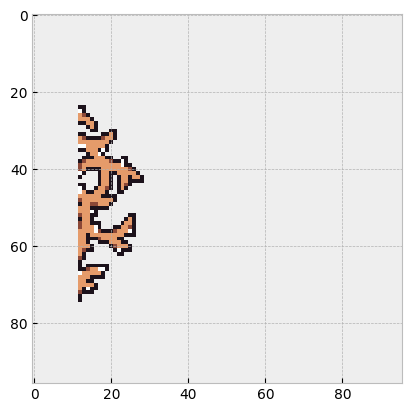

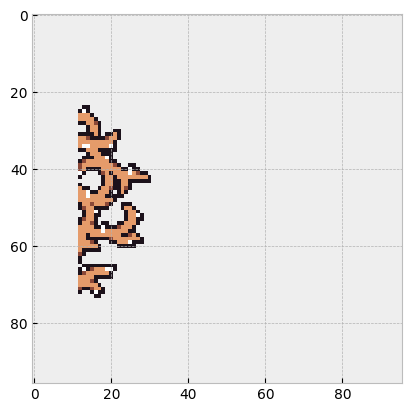

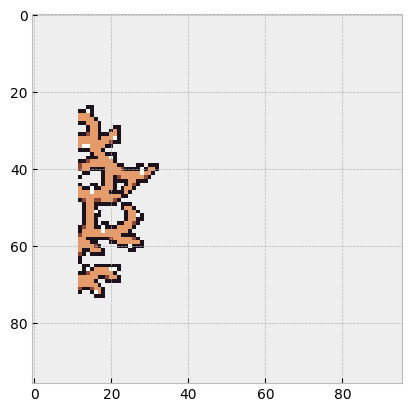

In [3]:
#@title Applying Formatting Functions to Dataset
Max_length = 96
dataset = convToArray(glob.glob("/content/Single_Sprite_Sheet/*.*"), Max_length)
random.shuffle(dataset)
print('Total set length' + str(len(dataset)))

'''
The dataset is originally a list of pixel art animations with 3+ frames each.
extractDataset() splits each animation into groups of 3 frames which follow eachother within the original animation.

dataset_x1 and dataset_x3 repersent frames 1 and 3 in the pixel art animation group.
The model will be trained to interpolate between these frames to create a new frame 2 which can be found in dataset_x2.
'''


dataset_x1, dataset_x2, dataset_x3 = extractDataset(dataset)

dataset_x1 = np.array(dataset_x1)
dataset_x2 = np.array(dataset_x2)
dataset_x3 = np.array(dataset_x3)

# Validation/ Test Set
test_x1 = dataset_x1[:20]
test_x2 = dataset_x2[:20]
test_x3 = dataset_x3[:20]

# Training Set
dataset_x1 = dataset_x1[20:]
dataset_x2 = dataset_x2[20:]
dataset_x3 = dataset_x3[20:]
print('Shape of formated training set:' +str(np.shape(dataset_x1)))

# example of
selec = 128
imgplot = plt.imshow(dataset_x1[selec])
plt.show()
imgplot = plt.imshow(dataset_x2[selec])
plt.show()
imgplot = plt.imshow(dataset_x3[selec])
plt.show()



# **Generation of Model**

---





In [5]:
#@title U-Net Encoder/Decoder
def Encoder(z_dim):
  inputs = layers.Input(shape = (Max_length, Max_length, 4))
  x = layers.Conv2D(filters=8, kernel_size= 5, strides=2, padding='same', activation='relu')(inputs)
  print(x.shape)
  x = layers.Conv2D(filters=12, kernel_size= 2, strides=2, padding='same', activation='relu')(x)
  print(x.shape)
  x = layers.Conv2D(filters=12, kernel_size= 2, strides=2, padding='same', activation='relu')(x)
  print(x.shape)
  x = layers.Conv2D(filters=16, kernel_size= 2, strides=1, padding='same', activation='relu')(x)
  print(x.shape)
  x = layers.Flatten()(x)
  print(x.shape)
  x = layers.Dense(z_dim, activation = 'relu')(x)
  print(x.shape)
  return tf.keras.Model(inputs = inputs, outputs = x, name = 'encoder')

def Decoder(z_dim):
  inputs = layers.Input(shape= (z_dim * 2,))
  x = layers.Dense(2*24*24*z_dim)(inputs)
  x = layers.Reshape((24,24,z_dim*2))(x)
  x = layers.Conv2D(filters=128, kernel_size=(2,2), strides=1, padding='same', activation='relu')(x)
  print(x.shape)
  x = layers.UpSampling2D((2,2))(x)
  print(x.shape)
  x = layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu')(x)
  print(x.shape)
  x = layers.UpSampling2D((2,2))(x)
  print(x.shape)
  x = layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu')(x)
  print(x.shape)
  x = layers.Conv2D(filters=4, kernel_size=(4,4), strides=1, padding='same', activation='sigmoid')(x)
  print(x.shape)
  return tf.keras.Model(inputs=inputs, outputs=x, name='decoder')


(None, 48, 48, 8)
(None, 24, 24, 12)
(None, 12, 12, 12)
(None, 12, 12, 16)
(None, 2304)
(None, 200)
(None, 48, 48, 8)
(None, 24, 24, 12)
(None, 12, 12, 12)
(None, 12, 12, 16)
(None, 2304)
(None, 200)
(None, 24, 24, 128)
(None, 48, 48, 128)
(None, 48, 48, 64)
(None, 96, 96, 64)
(None, 96, 96, 32)
(None, 96, 96, 4)


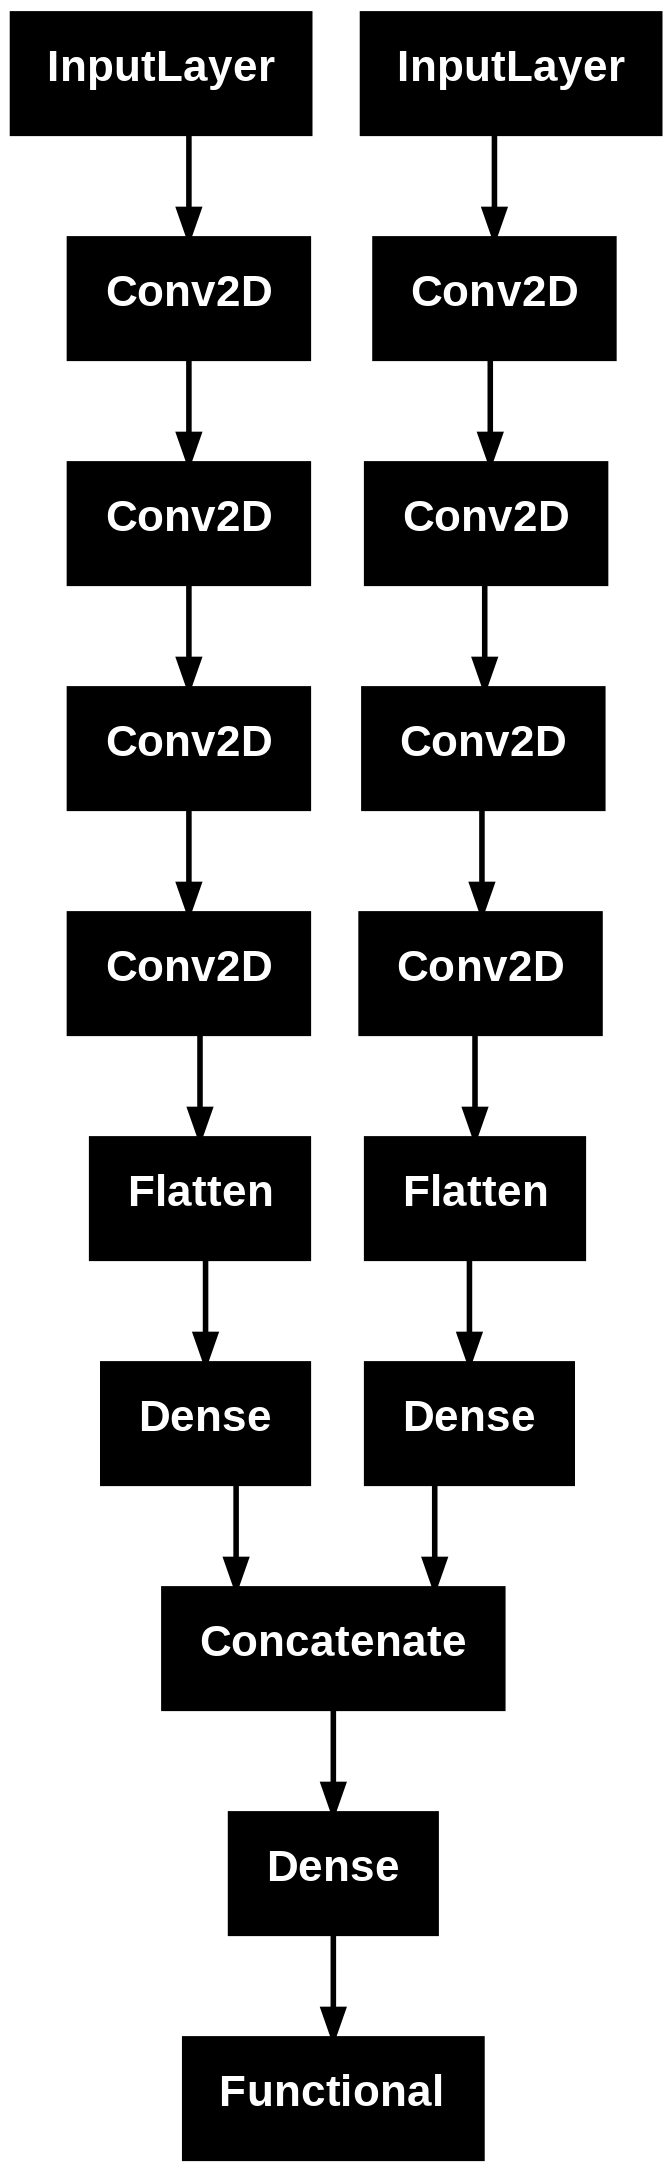

In [6]:
#@title U-Net Model
z_dim = 200
encoder = Encoder(z_dim)
encoder2 = Encoder(z_dim)
decoder = Decoder(z_dim)

combine = layers.Concatenate()([encoder.output, encoder2.output])
combine = layers.Dense(2*z_dim, activation = 'relu')(combine)
combine = decoder(combine)
autoencoder = tf.keras.Model(inputs = [encoder.input,encoder2.input], outputs = combine)
tf.keras.utils.plot_model(autoencoder)

In [ ]:
#@title U-Net Descriminator (INCOMPLETE)
'''
inputs = layers.Input(shape = (Max_length, Max_length, 4))
x = layers.Conv2D(filters=64, kernel_size= 5, strides=2, padding='same', activation='relu')(inputs)
print(x.shape)
x = layers.Conv2D(filters=64, kernel_size= 5, strides=2, padding='same', activation='relu')(x)
print(x.shape)
x = layers.Flatten()(x)
x = Layers.Dense(1)(x)

Descriminator = tf.keras.Model(inputs = [encoder.input, encoder2.input], outputs = x)
'''

"\ninputs = layers.Input(shape = (Max_length, Max_length, 4))\nx = layers.Conv2D(filters=64, kernel_size= 5, strides=2, padding='same', activation='relu')(inputs)\nprint(x.shape)\nx = layers.Conv2D(filters=64, kernel_size= 5, strides=2, padding='same', activation='relu')(x)\nprint(x.shape)\nx = layers.Flatten()(x)\nx = Layers.Dense(1)(x)\n\nDescriminator = tf.keras.Model(inputs = [encoder.input, encoder2.input], outputs = x)\n"

Epoch 1/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - loss: 0.0427
Epoch 2/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.0204
Epoch 3/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.0168
Epoch 4/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.0153
Epoch 5/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.0142
Epoch 6/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.0132
Epoch 7/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 0.0123
Epoch 8/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.0115
Epoch 9/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 0.0111
Epoch 10/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 0.0106
Epoch 11/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 0.0098
Epoch 12/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 0.0093
Epoch 13/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - loss: 0.0092
Epoch 14/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 0.0089
Epoch 15/35
159/159 ━━━━━━━━━━━━━━━━━━━━ 

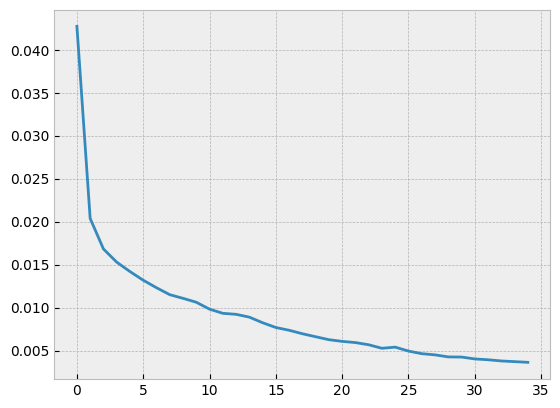

In [7]:
#@title Train Model
model = autoencoder
model.compile(loss = "mean_squared_error", optimizer = 'adam'  )
history = model.fit((dataset_x1,dataset_x3),dataset_x2, epochs = 35,verbose = 1)
plt.plot(history.history['loss'])
plt.show()

#**Model Post Prosceccing and Examination**




In [8]:
#@title Color Pre/Post Proscescing Functions
def calculateDistanceBetweenColors(a, b):
  r = abs(a[0] - b[0])
  g = abs(a[1] - b[1])
  bl = abs(a[2] - b[2])
  d = abs(a[3] - b[3])
  dis = (r+g+bl+d+d)/5
  return dis

def findClosestVal(histogram, val, lean, blank_color,blank_lean,border_color,border_lean):
  high = 1
  color = [0,0,0,0]
  if blank_color != None:
    if calculateDistanceBetweenColors(val, blank_color) < blank_lean:
      return blank_color
  if border_color != None:
    if calculateDistanceBetweenColors(val, border_color) < border_lean:
      return border_color
    return color

  for cnt in range(len(histogram)):
    i = histogram[cnt]
    if calculateDistanceBetweenColors(val, i) < high:
      high = calculateDistanceBetweenColors(val, i )
      color = i
  if high > lean:
    return val
  return color

def colorSearch(histogram, val, lean):
  high = 1
  for cnt in range(len(histogram)):
    i = histogram[cnt]
    if calculateDistanceBetweenColors(val, i) < high:
      high = calculateDistanceBetweenColors(val, i )
  if high > lean:
    return False
  return True



# Stores a histogram of all of the colors within the 2 given images. If a color is too similar to another
def colorHistogramEncoder(img1, img2):

  ColorHistogram = []
  for i in range(img1.shape[0]):
    for j in range(img1.shape[1]):
      if not colorSearch(ColorHistogram, img1[i][j],.01):
        ColorHistogram.append(img1[i][j])
    for i in range(img2.shape[0]):
      for j in range(img2.shape[1]):
        if not colorSearch(ColorHistogram, img2[i][j],.01):
          ColorHistogram.append(img2[i][j])
  return ColorHistogram


def colorHistogramDecoder(img, histogram, lean, blank_color,blank_lean,border_color,border_lean):
  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      img[i][j] = findClosestVal(histogram,img[i][j],lean, blank_color,blank_lean,border_color,border_lean)
  return img






Frame 1 (input)


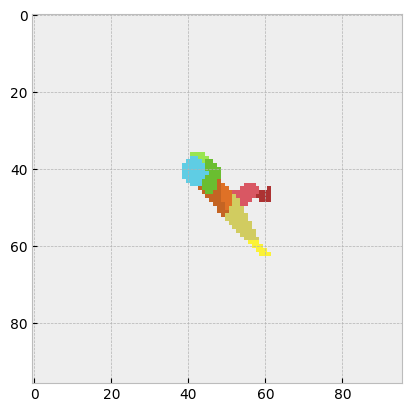

Frame 2 (desired result)


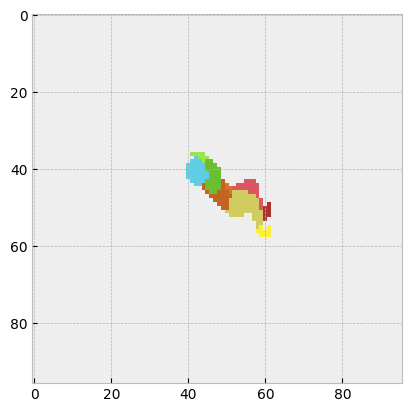

Frame 3 (input)


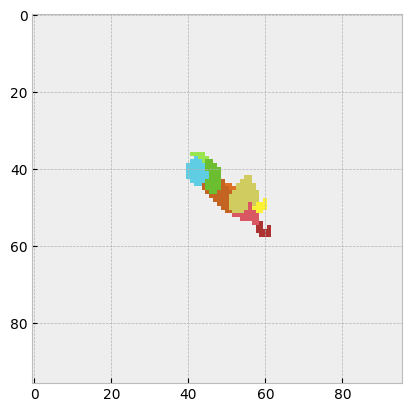

Frame 2 (Generated Result)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


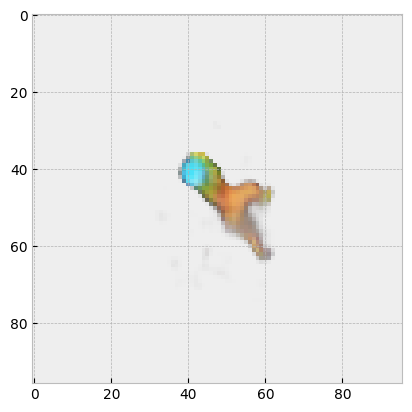

In [14]:
#@title Testing Base Model

selec = 16

print('Frame 1 (input)')
imgplot = plt.imshow(test_x1[selec])
plt.show()

print('Frame 2 (desired result)')
imgplot = plt.imshow(test_x2[selec])
plt.show()

print('Frame 3 (input)')
imgplot = plt.imshow(test_x3[selec])
plt.show()

print('Frame 2 (Generated Result)')
i = model.predict([test_x1[selec][np.newaxis],test_x3[selec][np.newaxis]])
i = i[0]
imgplot = plt.imshow(i)
plt.show()

[array([0., 0., 0., 0.], dtype=float32), array([0.6      , 0.8980392, 0.3137255, 1.       ], dtype=float32), array([0.37254903, 0.8039216 , 0.89411765, 1.        ], dtype=float32), array([0.41568628, 0.74509805, 0.1882353 , 1.        ], dtype=float32), array([0.81960785, 0.8       , 0.3764706 , 1.        ], dtype=float32), array([0.76862746, 0.39215687, 0.13725491, 1.        ], dtype=float32), array([0.8745098 , 0.44313726, 0.14901961, 1.        ], dtype=float32), array([0.9843137 , 0.9490196 , 0.21176471, 1.        ], dtype=float32), array([0.8509804 , 0.34117648, 0.3882353 , 1.        ], dtype=float32), array([0.9843137 , 0.9490196 , 0.21176471, 0.        ], dtype=float32), array([0.91764706, 0.6431373 , 0.29803923, 0.        ], dtype=float32), array([0.8509804 , 0.34117648, 0.3882353 , 0.        ], dtype=float32), array([0.8039216, 0.3019608, 0.3372549, 0.       ], dtype=float32), array([0.6745098 , 0.19607843, 0.19607843, 0.        ], dtype=float32), array([0.6745098 , 0.19607843, 

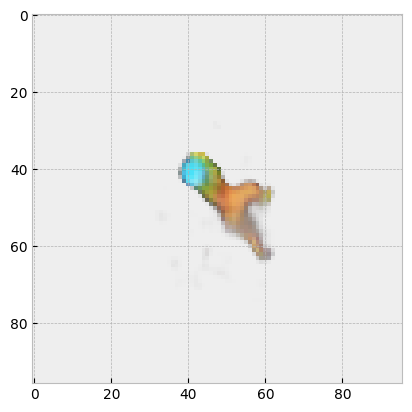

With Blur Reduction


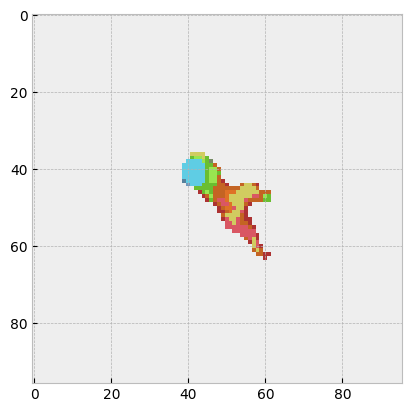

Desired Result Image


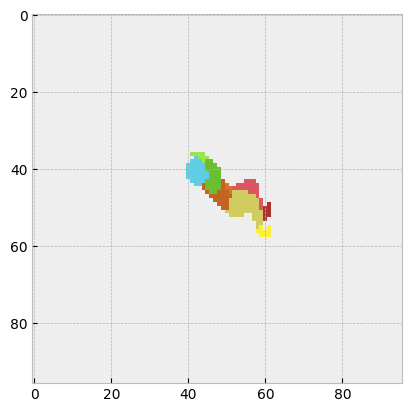

In [15]:

#@title Reducing Color Palate and Blur

'''
One of the major problems with the current model is that the outputs are too blurry.
Good Pixel Art usualy sticks to a color palate of ~10 colors; however, regions where 1 color should be filled in contain a multitude of similar shades to this color in the output.
To mitigate this issue, a histogram of all of the colors is created, similar colors are removed, and then a new image is produced.
'''

histogram = colorHistogramEncoder(test_x1[selec],test_x3[selec])
print(histogram)
border_color=[0,0,0,1]
blank_color=[0,0,0,0]

# Without Blur Reduction
print("without Blur Reduction")
imgplot = plt.imshow(i)
plt.show()

# With Blur Reduction
print("With Blur Reduction")
i = colorHistogramDecoder(i, histogram, .3 ,None,.5,None,.5)
imgplot = plt.imshow(i)
plt.show()

# Desired Result Image
print("Desired Result Image")
imgplot = plt.imshow(test_x2[selec])
plt.show()


#**Model Upload/Download**

In [ ]:
#@title download Keras Model

model.save('keras_model.keras')

#from google.colab import files
#files.download('keras_model.keras')

from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/ModelFolder/interpolationModel', save_format="h5")

#import shutil
#shutil.copy('source','destination')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
#@title upload Keras Model
from google.colab import drive
drive.mount('/content/drive')

model = tf.keras.models.load_model('/content/drive/MyDrive/ModelFolder/interpolationModel')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#@title Save and Download Model in ONNX Format
from google.colab import files

input_signature = [tf.TensorSpec([None, 96, 96, 4], tf.float32, name='input_1'),
                   tf.TensorSpec([None, 96, 96, 4], tf.float32, name='input_2')]

onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature, opset=13)
onnx.save(onnx_model, "/content/model.onnx")
files.download("/content/model.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@title Save and Download Model in CoreML Format

import coremltools

model.save('InterpModel1.h5')

CoreMLmodel = coremltools.convert(model, convert_to="mlprogram")
CoreMLmodel.save('InterpModel1.h5')
from google.colab import files
files.download('InterpModel1.h5')

In [ ]:
#@title Save Model in JSON and HDF5
# Save ful model in HDF5

model.save('full_model.h5')

# Save the config in JSON Format

model_json = model.to_json()
with open("model_config.json", "w") as f:
    f.write(model_json)

# Save Weights

model.save_weights('model_weights.h5')

# Download Everything

from google.colab import files
files.download("/content/model_config.json")
files.download("/content/model_weights.h5")
files.download("/content/full_model.h5")


In [ ]:
#@title Save Model in TFLITE
model_dir = 'saved_model/1'
tf.saved_model.save(model,model_dir,)
'''
//!zip -r /content/savedModel.zip /content/saved_model
'''
converter = tf.lite.TFLiteConverter.from_saved_model(model_dir)
tflite_model = converter.convert()
with open('model.tflite', 'wb') as f:
  f.write(tflite_model)
##from google.colab import files
#files.download("/content/model.tflite")